In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Ignore warning messages for cleaner output

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load the dataset

df = pd.read_csv(r"dataset\helth_care_dataset.csv")

df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


In [7]:
df.shape

(318438, 18)

In [8]:
df.info()

# Check missing values

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  str    
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  str    
 5   Available Extra Rooms in Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  str    
 7   Ward_Type                          318438 non-null  str    
 8   Ward_Facility_Code                 318438 non-null  str    
 9   Bed Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  313906 non-null

In [9]:
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276848,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [10]:
# Display target variable distribution

df['Stay'].value_counts()

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

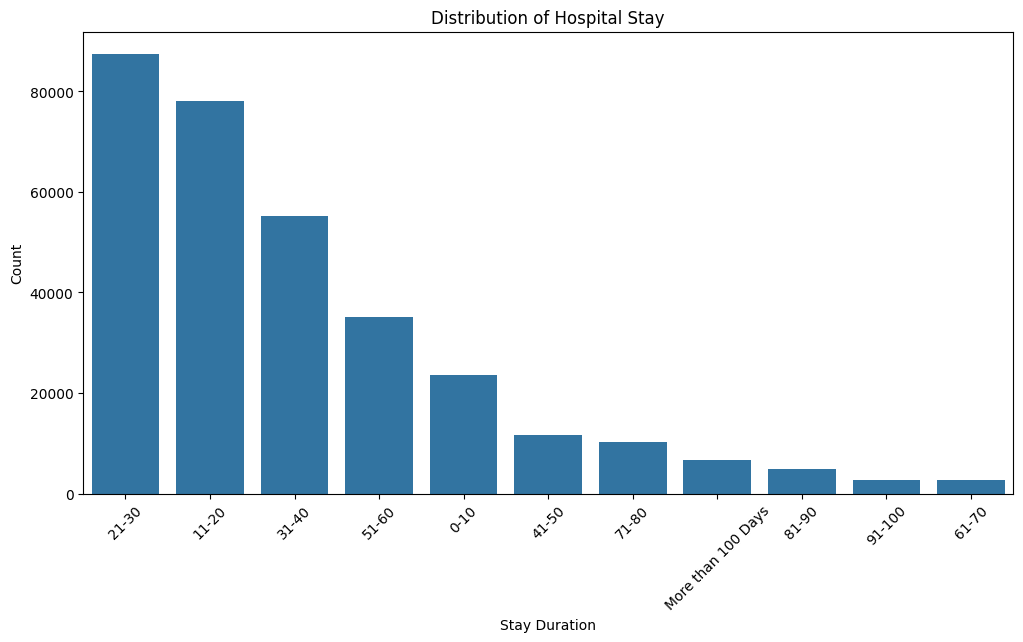

In [11]:
# Plot Stay distribution

plt.figure(figsize=(12,6))

sns.countplot(x='Stay', data=df, order=df['Stay'].value_counts().index)

plt.title("Distribution of Hospital Stay")
plt.xlabel("Stay Duration")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Insights

- The target variable (`Stay`) is imbalanced.
- Most patients stay between **11–40 days**.
- Very long stay durations such as **91–100 days** and **More than 100 Days** have fewer samples.
- Class imbalance may affect model performance, especially for minority classes.

### Next Step

- Handle missing values.
- Encode categorical features.
- Prepare the data for machine learning models.
- Consider techniques to handle class imbalance if needed.

In [16]:
# Drop unnecessary identifier columns

df.drop(['case_id', 'patientid'], axis=1, inplace=True)

In [17]:
df

,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,8,c,3,Z,3,radiotherapy,R,F,2.0,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,c,5,Z,2,radiotherapy,S,F,2.0,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,10,e,1,X,2,anesthesia,S,E,2.0,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,26,b,2,Y,2,radiotherapy,R,D,2.0,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,26,b,2,Y,2,radiotherapy,S,D,2.0,7.0,Trauma,Extreme,2,51-60,5558.0,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,6,a,6,X,3,radiotherapy,Q,F,4.0,23.0,Emergency,Moderate,3,41-50,4144.0,11-20
318434,24,a,1,X,2,anesthesia,Q,E,4.0,8.0,Urgent,Moderate,4,81-90,6699.0,31-40
318435,7,a,4,X,3,gynecology,R,F,4.0,10.0,Emergency,Minor,3,71-80,4235.0,11-20
318436,11,b,2,Y,3,anesthesia,Q,D,3.0,8.0,Trauma,Minor,5,11-20,3761.0,11-20


In [18]:
# Display categorical columns

categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:\n")

for col in categorical_cols:
    print(f"{col} --> {df[col].nunique()} unique values")

Categorical Columns:

Hospital_type_code --> 7 unique values
Hospital_region_code --> 3 unique values
Department --> 5 unique values
Ward_Type --> 6 unique values
Ward_Facility_Code --> 6 unique values
Type of Admission --> 3 unique values
Severity of Illness --> 3 unique values
Age --> 10 unique values
Stay --> 11 unique values


In [22]:
# Check missing values percentage

df.isnull().sum()

Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                             113
City_Code_Patient                    4532
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [27]:
# Fill missing values with mode

df['Bed Grade'] = df['Bed Grade'].fillna(df['Bed Grade'].mode()[0])

df['City_Code_Patient'] = df['City_Code_Patient'].fillna(
    df['City_Code_Patient'].mode()[0]
)

In [28]:
df.isnull().sum()

Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available Extra Rooms in Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed Grade                            0
City_Code_Patient                    0
Type of Admission                    0
Severity of Illness                  0
Visitors with Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64

## Feature Encoding

Machine learning models cannot work directly with categorical text values.

To prepare the dataset for model training, categorical features are converted into numerical values using **Label Encoding**.

This process assigns a unique integer value to each category in every categorical column.

In [30]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Initialize encoder

encoder = LabelEncoder()

# Store categorical columns

categorical_cols = df.select_dtypes(include='object').columns

# Apply label encoding

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])



In [32]:
df.head(15)

,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,8,2,3,2,3,3,2,5,2.0,7.0,0,0,2,5,4911.0,0
1,2,2,5,2,2,3,3,5,2.0,7.0,1,0,2,5,5954.0,4
2,10,4,1,0,2,1,3,4,2.0,7.0,1,0,2,5,4745.0,3
3,26,1,2,1,2,3,2,3,2.0,7.0,1,0,2,5,7272.0,4
4,26,1,2,1,2,3,3,3,2.0,7.0,1,0,2,5,5558.0,4
5,23,0,6,0,2,1,3,5,2.0,7.0,1,0,2,5,4449.0,1
6,32,5,9,1,1,3,3,1,3.0,7.0,0,0,2,5,6167.0,0
7,23,0,6,0,4,3,1,5,3.0,7.0,1,0,2,5,5571.0,4
8,1,3,10,1,2,2,2,1,4.0,7.0,1,0,2,5,7223.0,5
9,10,4,1,0,2,2,3,4,3.0,7.0,1,0,2,5,6056.0,3


In [33]:
# Check data types after encoding

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Hospital_code                      318438 non-null  int64  
 1   Hospital_type_code                 318438 non-null  int64  
 2   City_Code_Hospital                 318438 non-null  int64  
 3   Hospital_region_code               318438 non-null  int64  
 4   Available Extra Rooms in Hospital  318438 non-null  int64  
 5   Department                         318438 non-null  int64  
 6   Ward_Type                          318438 non-null  int64  
 7   Ward_Facility_Code                 318438 non-null  int64  
 8   Bed Grade                          318438 non-null  float64
 9   City_Code_Patient                  318438 non-null  float64
 10  Type of Admission                  318438 non-null  int64  
 11  Severity of Illness                318438 non-null

## Dataset Splitting

The dataset is divided into:

- Training set → used for model training
- Validation set → used for model evaluation and tuning
- Test set → used for final performance evaluation


In [34]:
# Split features and target variable

X = df.drop('Stay', axis=1)

y = df['Stay']

In [35]:
# Split data into training and temporary sets

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [36]:
# Split temporary data into validation and test sets

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [37]:
# Display dataset shapes

print("Training Set Shape :", X_train.shape)
print("Validation Set Shape :", X_val.shape)
print("Test Set Shape :", X_test.shape)

Training Set Shape : (222906, 15)
Validation Set Shape : (47766, 15)
Test Set Shape : (47766, 15)


## Handling Class Imbalance with SMOTE

The target variable contains imbalanced classes.

To improve the model’s ability to learn minority classes, the SMOTE technique is applied only to the training set.

This helps generate synthetic samples for underrepresented classes while preventing data leakage.

In [40]:
# Import SMOTE for handling class imbalance

from imblearn.over_sampling import SMOTE

In [41]:
# Apply SMOTE to balance the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


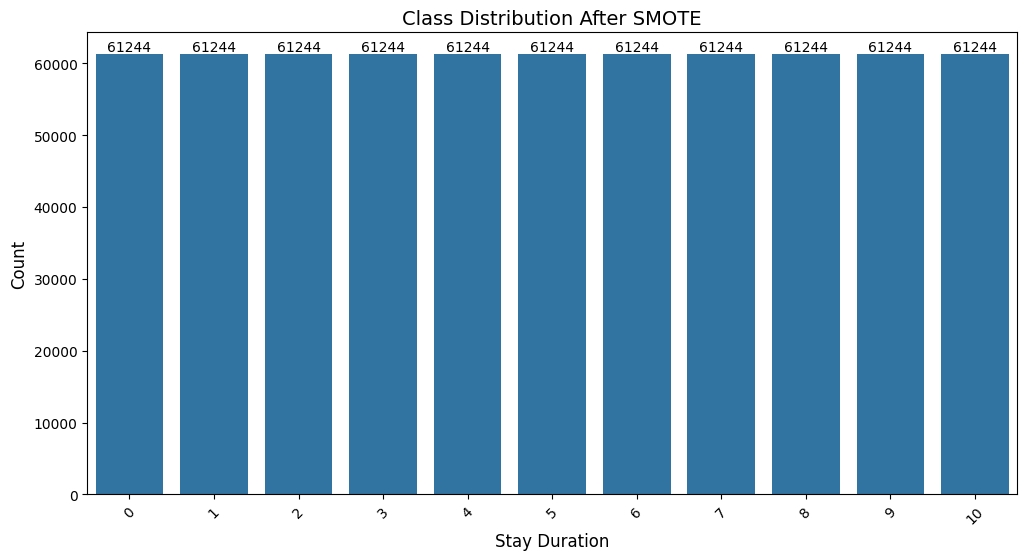

In [43]:
# Visualize balanced class distribution after SMOTE

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x=y_train_smote,
    order=sorted(y_train_smote.unique())
)



plt.title("Class Distribution After SMOTE", fontsize=14)

plt.xlabel("Stay Duration", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

# Display count values on bars

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

### Observation

After applying SMOTE, all target classes became balanced with approximately the same number of samples.

This helps reduce model bias toward majority classes and improves learning for minority classes.

## Model Training

A Random Forest Classifier is used as the baseline machine learning model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [46]:
# Import Random Forest model

from sklearn.ensemble import RandomForestClassifier

In [47]:
# Initialize the model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)



In [48]:
# Train the model

rf_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
# Predict on validation data

y_pred = rf_model.predict(X_val)

In [50]:
# Calculate model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)



In [53]:
print(f"Validation Accuracy: {accuracy:.2%}")

Validation Accuracy: 36.58%


In [54]:
# Display classification report

from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.27      0.25      0.26      3541
           1       0.39      0.41      0.40     11721
           2       0.42      0.49      0.45     13123
           3       0.32      0.24      0.28      8274
           4       0.08      0.05      0.06      1762
           5       0.38      0.45      0.41      5253
           6       0.05      0.02      0.03       411
           7       0.19      0.12      0.15      1538
           8       0.28      0.28      0.28       725
           9       0.16      0.07      0.09       415
          10       0.41      0.49      0.45      1003

    accuracy                           0.37     47766
   macro avg       0.27      0.26      0.26     47766
weighted avg       0.35      0.37      0.36     47766



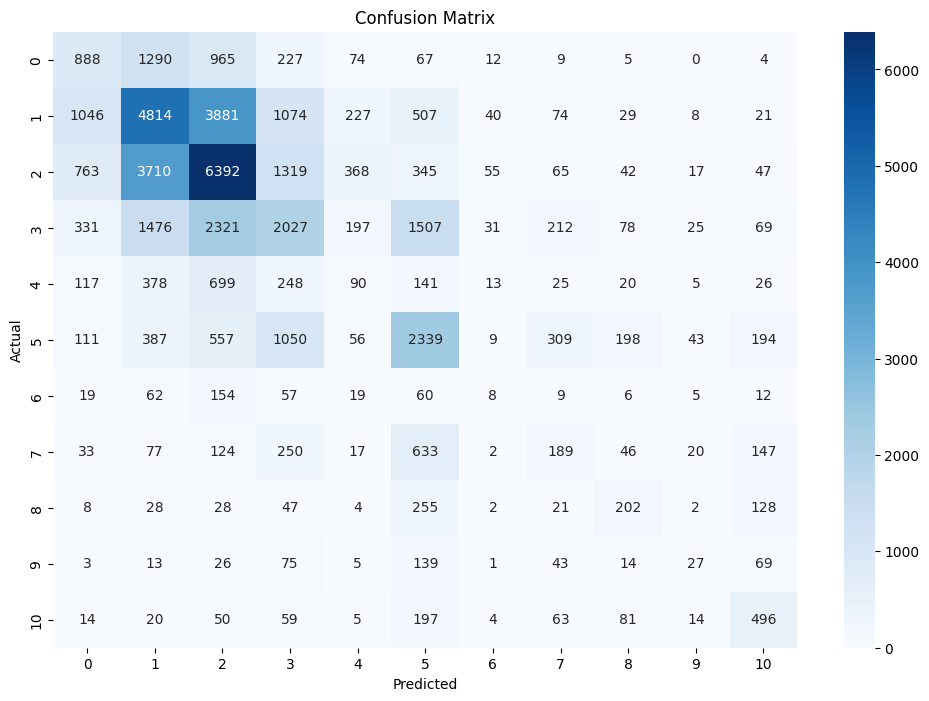

In [55]:
# Plot confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Performance Analysis

The Random Forest model achieved moderate performance on the validation set.

Although SMOTE improved class balance during training, the model still struggles with minority classes and closely related stay durations.

The confusion matrix shows that many predictions are concentrated around neighboring classes, indicating overlap between hospital stay categories.

Further improvements may include:
- Trying more advanced models such as XGBoost
- Hyperparameter tuning
- Additional feature engineering

## XGBoost Model Training

XGBoost is an advanced gradient boosting algorithm known for its strong performance on structured and tabular datasets.

It is used here to improve prediction accuracy and better handle complex relationships between features and target classes.

In [56]:
# Import XGBoost classifier

from xgboost import XGBClassifier

In [57]:
# Initialize XGBoost model

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=11,
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)


In [58]:
# Train the model

xgb_model.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [59]:
# Predict on validation set

y_pred_xgb = xgb_model.predict(X_val)

In [61]:
# Calculate validation accuracy

xgb_accuracy = accuracy_score(y_val, y_pred_xgb)

print(f"XGBoost Validation Accuracy: {xgb_accuracy:.2%}")

XGBoost Validation Accuracy: 40.29%


In [62]:
# Display classification report

print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.32      0.24      0.27      3541
           1       0.44      0.46      0.45     11721
           2       0.43      0.63      0.51     13123
           3       0.41      0.19      0.26      8274
           4       0.08      0.03      0.04      1762
           5       0.40      0.43      0.41      5253
           6       0.05      0.02      0.03       411
           7       0.14      0.04      0.06      1538
           8       0.22      0.38      0.28       725
           9       0.08      0.04      0.05       415
          10       0.40      0.49      0.44      1003

    accuracy                           0.40     47766
   macro avg       0.27      0.27      0.25     47766
weighted avg       0.38      0.40      0.38     47766



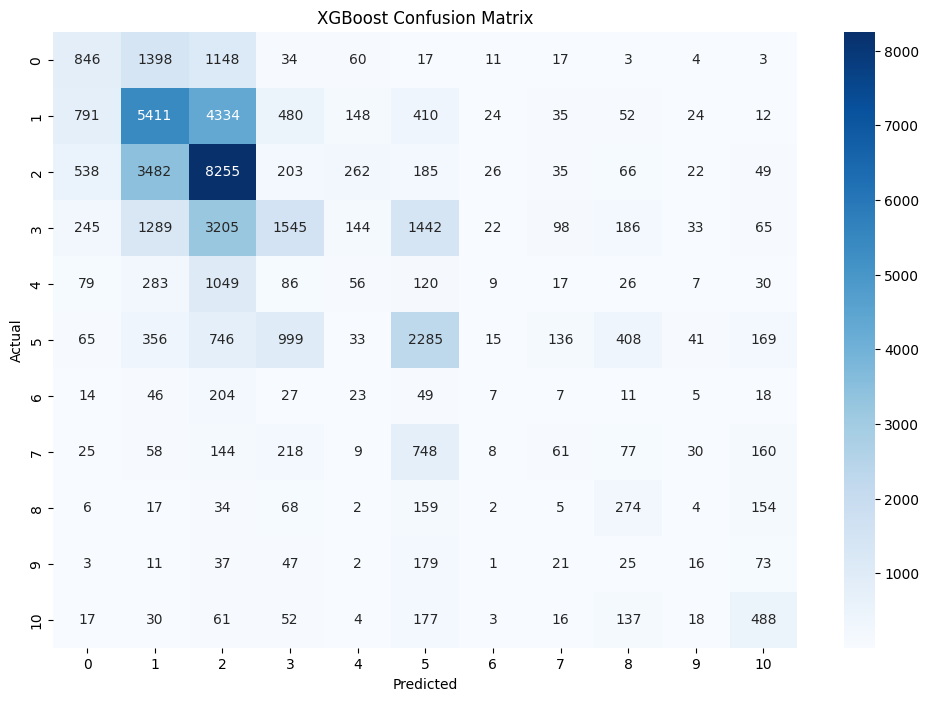

In [63]:
# Generate confusion matrix

cm_xgb = confusion_matrix(y_val, y_pred_xgb)

# Plot confusion matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## XGBoost Performance Analysis

The XGBoost model achieved better performance compared to the Random Forest model.

- Validation accuracy improved from approximately **36%** to **40%**.
- The model showed better prediction capability for several major classes.
- However, some minority classes still have low recall and F1-scores.

The confusion matrix also indicates that many prediction errors occur between neighboring stay duration categories, suggesting overlap between similar hospital stay ranges.

Further improvements may include:
- Trying more advanced ensemble methods such as CatBoost
- Additional feature engineering


## CatBoost Model Training

CatBoost is a gradient boosting algorithm designed to handle categorical and tabular data efficiently.

It is known for strong performance, reduced overfitting, and better handling of complex feature relationships.

In [64]:
# Import CatBoost classifier

from catboost import CatBoostClassifier

In [65]:
# Initialize CatBoost model

cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=8,
    loss_function='MultiClass',
    random_state=42,
    verbose=0
)



In [66]:
# Train the model

cat_model.fit(X_train_smote, y_train_smote)

CatBoostClassifier(depth=8, iterations=100, learning_rate=0.1, loss_function='MultiClass', random_state=42, verbose=0)

In [67]:
# Predict on validation data

y_pred_cat = cat_model.predict(X_val)

In [69]:
# Calculate validation accuracy

cat_accuracy = accuracy_score(y_val, y_pred_cat)

print(f"CatBoost Validation Accuracy: {cat_accuracy:.2%}")

CatBoost Validation Accuracy: 38.94%


In [70]:
# Display classification report

print(classification_report(y_val, y_pred_cat))

              precision    recall  f1-score   support

           0       0.28      0.26      0.27      3541
           1       0.42      0.48      0.45     11721
           2       0.44      0.56      0.49     13123
           3       0.37      0.15      0.21      8274
           4       0.09      0.05      0.07      1762
           5       0.39      0.47      0.42      5253
           6       0.04      0.01      0.02       411
           7       0.16      0.03      0.05      1538
           8       0.19      0.39      0.25       725
           9       0.06      0.03      0.04       415
          10       0.40      0.49      0.44      1003

    accuracy                           0.39     47766
   macro avg       0.26      0.27      0.25     47766
weighted avg       0.37      0.39      0.37     47766



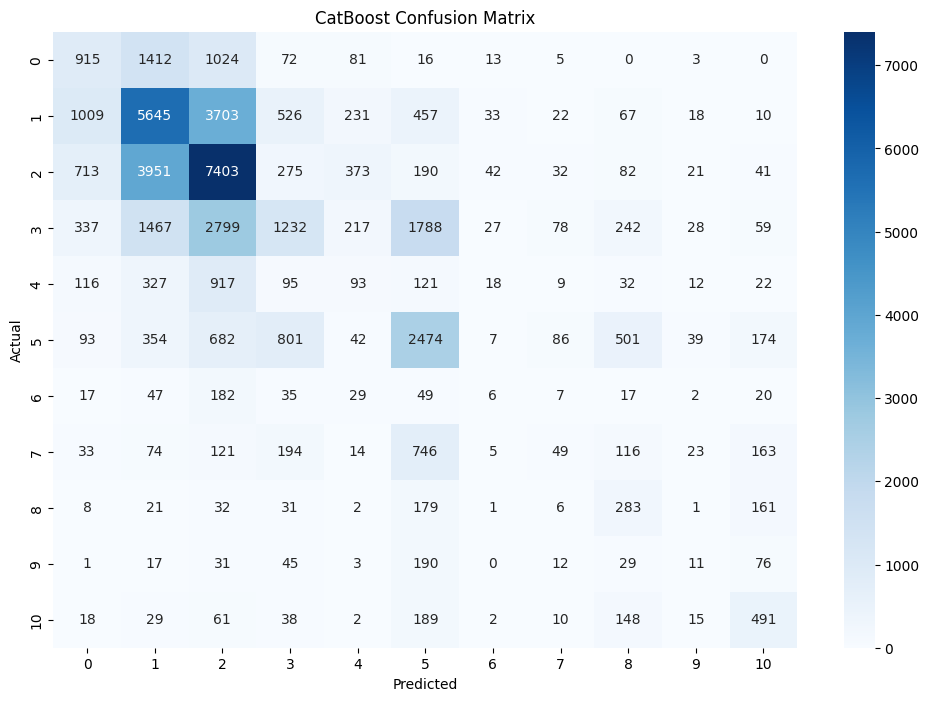

In [71]:
# Generate confusion matrix

cm_cat = confusion_matrix(y_val, y_pred_cat)

# Plot confusion matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    cm_cat,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparison and Evaluation

Three machine learning models were trained and evaluated on the validation dataset:

| Model | Validation Accuracy |
|--------|---------------------|
| Random Forest | 36.58% |
| CatBoost | 38.94% |
| XGBoost | 40.29% |

### Observations

- XGBoost achieved the best overall performance among the tested models.
- CatBoost performed better than Random Forest but slightly lower than XGBoost.
- The models showed good performance on majority classes but still struggled with minority classes despite applying SMOTE.
- Many prediction errors occurred between neighboring stay duration categories, indicating overlap between similar hospital stay ranges.

### Conclusion

Based on the validation results, **XGBoost** was selected as the best-performing model for this project due to its higher accuracy and better overall class prediction performance.

## Deep Neural Network (DNN)

A Deep Neural Network is trained to explore whether deep learning techniques can improve prediction performance on the hospital stay duration dataset.

Before training the neural network, feature scaling is applied to normalize the input data and improve model convergence.

In [72]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [73]:
# Initialize scaler

scaler = StandardScaler()

# Scale data for DNN only

X_train_dnn = scaler.fit_transform(X_train_smote)

X_val_dnn = scaler.transform(X_val)

X_test_dnn = scaler.transform(X_test)

In [76]:
# Import TensorFlow and Keras libraries

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

In [77]:
# Build a deeper DNN model

dnn_model = Sequential([

    Dense(256, activation='relu', input_shape=(X_train_dnn.shape[1],)),

    Dropout(0.4),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(11, activation='softmax')
])

In [78]:
# Import EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

In [79]:
# Define EarlyStopping callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [80]:
# Compile the model

dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
# Display model architecture

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,691 (186.29 KB)

 Trainable params: 47,691 (186.29 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# Train the DNN model

history = dnn_model.fit(
    X_train_dnn,
    y_train_smote,
    validation_data=(X_val_dnn, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.3048 - loss: 1.8709 - val_accuracy: 0.3402 - val_loss: 1.7536
Epoch 2/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.3400 - loss: 1.7719 - val_accuracy: 0.3549 - val_loss: 1.6891
Epoch 3/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3483 - loss: 1.7472 - val_accuracy: 0.3598 - val_loss: 1.6668
Epoch 4/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3521 - loss: 1.7333 - val_accuracy: 0.3595 - val_loss: 1.6665
Epoch 5/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3557 - loss: 1.7239 - val_accuracy: 0.3721 - val_loss: 1.6492
Epoch 6/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3578 - loss: 1.7175 - val_accuracy: 0.3694 - val_loss: 1.6539
Epoch 7/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3594 - loss: 1.7120 - val_accuracy: 0.3630 - val_loss: 1.6545
Epoch 8/50
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3612 - loss: 1

## Deep Neural Network Performance

A Deep Neural Network (DNN) was trained using scaled data and multiple dense layers with dropout regularization.

The model showed stable learning behavior during training and achieved competitive validation performance. However, the DNN did not outperform the XGBoost model on this tabular dataset.

This result aligns with common observations in structured data problems, where gradient boosting models often outperform deep learning approaches.

## Feature Importance Analysis with XGBoost

Since XGBoost achieved the best validation performance among all tested models, feature importance analysis will be performed using the trained XGBoost model.

This analysis helps identify the most influential features affecting hospital stay duration predictions.

In [84]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_
})

In [85]:
# Sort feature importance values

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top features

feature_importance.head(10)

,Feature,Importance
12,Visitors with Patient,0.348171
6,Ward_Type,0.108755
8,Bed Grade,0.066242
10,Type of Admission,0.063998
3,Hospital_region_code,0.063897
4,Available Extra Rooms in Hospital,0.058733
7,Ward_Facility_Code,0.052168
2,City_Code_Hospital,0.042346
1,Hospital_type_code,0.035737
9,City_Code_Patient,0.034097


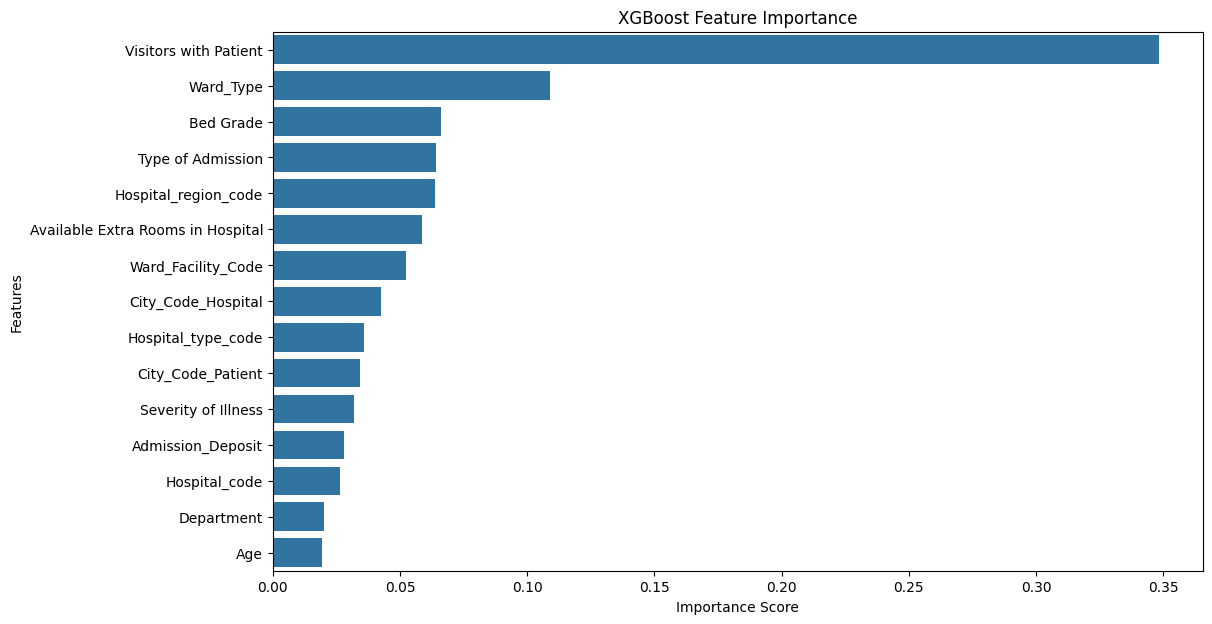

In [86]:
# Plot feature importance

plt.figure(figsize=(12,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

## Feature Selection

Feature selection is applied based on XGBoost feature importance scores.

Low-impact features are removed to reduce noise, simplify the model, and potentially improve generalization performance.

In [87]:
# Remove low-importance features

selected_features = X.drop([
    'Age',
    'Department',
    'Hospital_code',
    'Admission_Deposit'
], axis=1)

# Display remaining features

selected_features.columns

Index(['Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code',
       'Available Extra Rooms in Hospital', 'Ward_Type', 'Ward_Facility_Code',
       'Bed Grade', 'City_Code_Patient', 'Type of Admission',
       'Severity of Illness', 'Visitors with Patient'],
      dtype='str')

In [88]:
# Use selected features only

X_selected = selected_features

y_selected = y

In [89]:
# Split selected feature dataset

X_train_sel, X_temp_sel, y_train_sel, y_temp_sel = train_test_split(
    X_selected,
    y_selected,
    test_size=0.30,
    random_state=42,
    stratify=y_selected
)



In [90]:
# Validation and test split

X_val_sel, X_test_sel, y_val_sel, y_test_sel = train_test_split(
    X_temp_sel,
    y_temp_sel,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_sel
)

In [91]:
# Apply SMOTE on selected features

smote = SMOTE(random_state=42)

X_train_sel_smote, y_train_sel_smote = smote.fit_resample(
    X_train_sel,
    y_train_sel
)

In [92]:
# Train XGBoost using selected features

xgb_selected = XGBClassifier(
    objective='multi:softmax',
    num_class=11,
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)



In [93]:
xgb_selected.fit(
    X_train_sel_smote,
    y_train_sel_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [94]:
# Predict validation set

y_pred_sel = xgb_selected.predict(X_val_sel)

# Calculate accuracy

selected_accuracy = accuracy_score(
    y_val_sel,
    y_pred_sel
)

print(f"Selected Features Accuracy: {selected_accuracy:.2%}")

Selected Features Accuracy: 31.73%


In [95]:
df

,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,8,2,3,2,3,3,2,5,2.0,7.0,0,0,2,5,4911.0,0
1,2,2,5,2,2,3,3,5,2.0,7.0,1,0,2,5,5954.0,4
2,10,4,1,0,2,1,3,4,2.0,7.0,1,0,2,5,4745.0,3
3,26,1,2,1,2,3,2,3,2.0,7.0,1,0,2,5,7272.0,4
4,26,1,2,1,2,3,3,3,2.0,7.0,1,0,2,5,5558.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,6,0,6,0,3,3,1,5,4.0,23.0,0,2,3,4,4144.0,1
318434,24,0,1,0,2,1,1,4,4.0,8.0,2,2,4,8,6699.0,3
318435,7,0,4,0,3,2,2,5,4.0,10.0,0,1,3,7,4235.0,1
318436,11,1,2,1,3,1,1,3,3.0,8.0,1,1,5,1,3761.0,1


In [96]:
# Remove low-impact city code features

df.drop([
    'City_Code_Patient',
    'City_Code_Hospital'
], axis=1, inplace=True)

In [98]:
# Define features and target

X = df.drop('Stay', axis=1)

y = df['Stay']

In [99]:
# Split dataset

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [100]:
# Apply SMOTE on training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [101]:
# Train XGBoost

xgb_engineered = XGBClassifier(
    objective='multi:softmax',
    num_class=11,
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_engineered.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [102]:
# Predict validation data

y_pred_eng = xgb_engineered.predict(X_val)

In [103]:
# Calculate validation accuracy

eng_accuracy = accuracy_score(
    y_val,
    y_pred_eng
)

print(f"Engineered Features Accuracy: {eng_accuracy:.2%}")

Engineered Features Accuracy: 38.86%


## Feature Engineering

Feature engineering is applied to create new informative variables from the existing dataset.

These engineered features aim to capture hidden relationships between patient condition, hospital information, and hospitalization duration in order to improve model performance.

In [104]:
# Create interaction-based features

df['Severity_Visitors'] = (
    df['Severity of Illness'] *
    df['Visitors with Patient']
)

df['Deposit_per_Visitor'] = (
    df['Admission_Deposit'] /
    (df['Visitors with Patient'] + 1)
)

In [105]:
# Display engineered features

df[[
    'Severity_Visitors',
    'Deposit_per_Visitor'
]].head()

,Severity_Visitors,Deposit_per_Visitor
0,0,1637.000000
1,0,1984.666667
2,0,1581.666667
3,0,2424.000000
4,0,1852.666667


In [106]:
# Define features and target variable

X = df.drop('Stay', axis=1)

y = df['Stay']

In [107]:
# Split dataset into train, validation, and test sets

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [108]:
# Apply SMOTE to training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [109]:
# Train XGBoost model on engineered features

xgb_engineered = XGBClassifier(
    objective='multi:softmax',
    num_class=11,
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_engineered.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [110]:
# Predict validation set

y_pred_eng = xgb_engineered.predict(X_val)

In [111]:
# Calculate validation accuracy

eng_accuracy = accuracy_score(
    y_val,
    y_pred_eng
)

print(f"Feature Engineered Accuracy: {eng_accuracy:.2%}")

Feature Engineered Accuracy: 40.15%


## Hyperparameter Tuning

Hyperparameter tuning is applied to optimize the XGBoost model configuration and improve prediction performance.

Different parameter combinations are tested to achieve better generalization and classification accuracy.

In [112]:
# Train tuned XGBoost model

xgb_tuned = XGBClassifier(
    objective='multi:softmax',
    num_class=11,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)



In [113]:
xgb_tuned.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [114]:
# Predict validation set using tuned model

y_pred_tuned = xgb_tuned.predict(X_val)

In [116]:
# Calculate tuned model accuracy

tuned_accuracy = accuracy_score(
    y_val,
    y_pred_tuned
)

print(f"Tuned XGBoost Accuracy: {tuned_accuracy:.2%}")

Tuned XGBoost Accuracy: 40.62%


## Class Grouping

The original target variable contains 11 highly overlapping hospital stay categories.

To simplify the classification task and improve model performance, the stay durations are grouped into three broader categories:

- Short Stay
- Medium Stay
- Long Stay

This grouping reduces class overlap and creates a more practical prediction problem.

In [117]:
# Create grouped target classes

def group_stay(stay):

    if stay in [0, 1]:
        return 0   # Short Stay

    elif stay in [2, 3, 4]:
        return 1   # Medium Stay

    else:
        return 2   # Long Stay


# Apply grouping

df['Stay_Grouped'] = df['Stay'].apply(group_stay)

In [118]:
# Display grouped class distribution

df['Stay_Grouped'].value_counts()

Stay_Grouped
1    154393
0    101743
2     62302
Name: count, dtype: int64

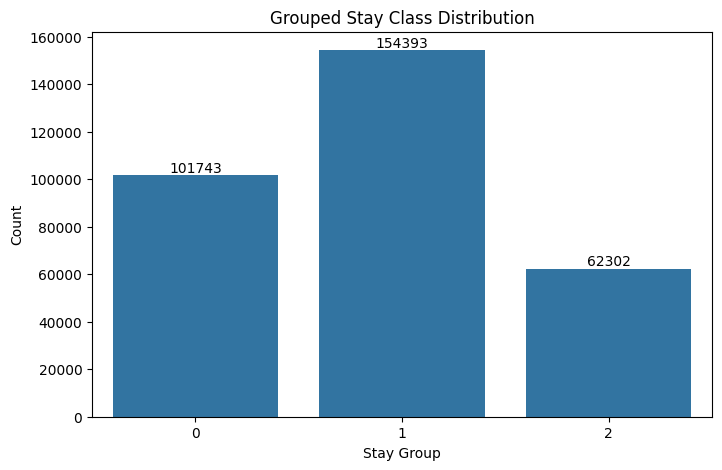

In [119]:
# Plot grouped class distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Stay_Grouped',
    data=df
)

plt.title("Grouped Stay Class Distribution")

plt.xlabel("Stay Group")

plt.ylabel("Count")

# Add count labels

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

## Training XGBoost on Grouped Classes

The XGBoost model is retrained using the grouped target classes.

This simplified classification setup helps reduce overlap between similar hospital stay durations and improves model learning capability.

In [120]:
# Define features and grouped target

X = df.drop(['Stay', 'Stay_Grouped'], axis=1)

y = df['Stay_Grouped']

In [121]:
# Split dataset

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [122]:
# Apply SMOTE to grouped classes

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [123]:
# Train XGBoost on grouped classes

xgb_grouped = XGBClassifier(
    objective='multi:softmax',
    num_class=3,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)



In [124]:
xgb_grouped.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [125]:
# Predict validation set

y_pred_grouped = xgb_grouped.predict(X_val)

In [126]:
# Calculate grouped model accuracy

grouped_accuracy = accuracy_score(
    y_val,
    y_pred_grouped
)

print(f"Grouped Classes Accuracy: {grouped_accuracy:.2%}")

Grouped Classes Accuracy: 61.53%


## Grouped Classes Model Evaluation

The grouped classification approach significantly improved model performance.

By reducing the number of highly overlapping target categories, the model achieved better generalization and more stable predictions across the grouped hospital stay durations.

In [127]:
# Display classification report

print(classification_report(
    y_val,
    y_pred_grouped
))

              precision    recall  f1-score   support

           0       0.57      0.51      0.54     15261
           1       0.62      0.65      0.64     23159
           2       0.67      0.70      0.68      9346

    accuracy                           0.62     47766
   macro avg       0.62      0.62      0.62     47766
weighted avg       0.61      0.62      0.61     47766



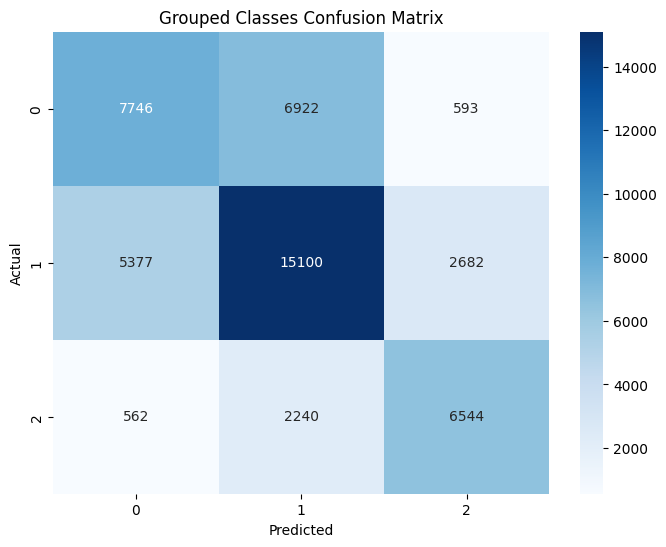

In [128]:
# Generate confusion matrix

cm_grouped = confusion_matrix(
    y_val,
    y_pred_grouped
)

# Plot confusion matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_grouped,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Grouped Classes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Model Performance Analysis

The grouped classification approach produced a significant improvement compared to the original 11-class setup.

The model achieved:

- Accuracy: 61.53%
- Macro F1-Score: 0.62
- Weighted F1-Score: 0.61

The confusion matrix also showed a noticeable reduction in class overlap and prediction confusion.

Most misclassifications occurred between neighboring stay-duration groups, which is expected due to the similarity between medium and long hospitalization cases.

Overall, the grouped-target strategy improved model stability, class balance, and generalization performance.

## Ordinal Feature Engineering

Some categorical variables contain natural ordered relationships.

Ordinal encoding is applied to preserve the logical order between categories and improve model understanding of feature progression.

In [129]:
# Proper ordinal encoding for ordered features

# Severity Encoding

severity_map = {
    'Minor': 0,
    'Moderate': 1,
    'Extreme': 2
}

# Age Encoding

age_map = {
    '0-10': 0,
    '11-20': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9
}

# Apply mappings

df['Severity of Illness'] = df['Severity of Illness'].map(severity_map)

df['Age'] = df['Age'].map(age_map)

In [130]:
# Complete age encoding

age_map = {
    '0-10': 0,
    '11-20': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9
}

In [131]:
# Apply ordinal encoding

df['Severity of Illness'] = df['Severity of Illness'].map(severity_map)

df['Age'] = df['Age'].map(age_map)

In [132]:
# Preview encoded columns

df[['Severity of Illness', 'Age']].head()

,Severity of Illness,Age
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [134]:
# Reload original dataset

df = pd.read_csv(r"dataset\helth_care_dataset.csv")

In [135]:
# Fill missing values using mode

df['Bed Grade'] = df['Bed Grade'].fillna(
    df['Bed Grade'].mode()[0]
)

df['City_Code_Patient'] = df['City_Code_Patient'].fillna(
    df['City_Code_Patient'].mode()[0]
)

In [136]:
# Drop unnecessary columns

df.drop([
    'case_id',
    'patientid'
], axis=1, inplace=True)

In [137]:
# Ordinal encoding for ordered categorical features

severity_map = {
    'Minor': 0,
    'Moderate': 1,
    'Extreme': 2
}

age_map = {
    '0-10': 0,
    '11-20': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9
}

stay_map = {
    '0-10': 0,
    '11-20': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9,
    'More than 100 Days': 10
}

# Apply ordinal encoding

df['Severity of Illness'] = df['Severity of Illness'].map(severity_map)

df['Age'] = df['Age'].map(age_map)

df['Stay'] = df['Stay'].map(stay_map)

In [138]:
# Label encoding for remaining categorical features

from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Hospital_type_code',
    'Hospital_region_code',
    'Department',
    'Ward_Type',
    'Ward_Facility_Code',
    'Type of Admission'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [139]:
# Create grouped target classes

def group_stay(stay):

    if stay in [0, 1]:
        return 0

    elif stay in [2, 3, 4]:
        return 1

    else:
        return 2


df['Stay_Grouped'] = df['Stay'].apply(group_stay)

In [140]:
# Create engineered features

df['Severity_Visitors'] = (
    df['Severity of Illness'] *
    df['Visitors with Patient']
)

df['Deposit_per_Visitor'] = (
    df['Admission_Deposit'] /
    (df['Visitors with Patient'] + 1)
)

In [141]:
# Define features and target

X = df.drop(['Stay', 'Stay_Grouped'], axis=1)

y = df['Stay_Grouped']

In [142]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [143]:
# Apply SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [144]:
# Train tuned XGBoost model

from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    objective='multi:softmax',
    num_class=3,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [145]:
# Predict and evaluate model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred_final = xgb_final.predict(X_val)

final_accuracy = accuracy_score(
    y_val,
    y_pred_final
)

print(f"Final Accuracy: {final_accuracy:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_val,
    y_pred_final
))

Final Accuracy: 0.6282

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.51      0.54     15261
           1       0.63      0.68      0.65     23159
           2       0.69      0.69      0.69      9346

    accuracy                           0.63     47766
   macro avg       0.63      0.63      0.63     47766
weighted avg       0.63      0.63      0.63     47766



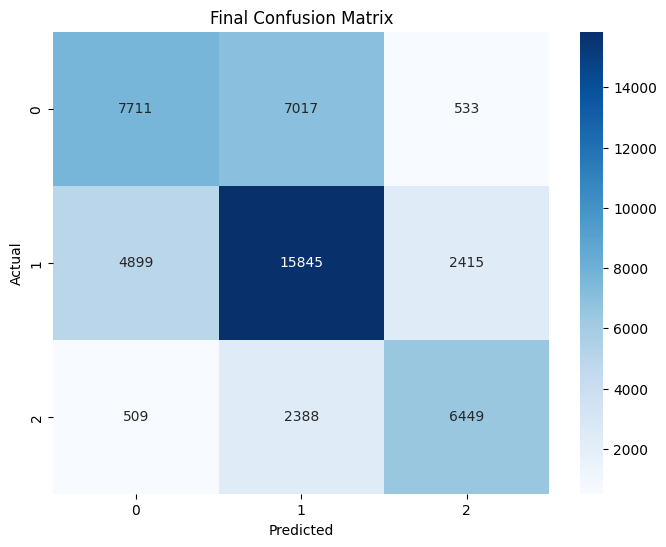

In [146]:
# Plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_val,
    y_pred_final
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Final Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Final Project Summary

## Project Title
Hospital Stay Duration Prediction Using Machine Learning

---

## Objective

The main objective of this project was to predict the expected hospital stay duration of patients based on hospital, patient, and admission-related features using machine learning techniques.

---

## Dataset Overview

The dataset contained:

- 318,438 patient records
- 18 original features
- Mixed numerical and categorical data
- Missing values in:
  - Bed Grade
  - City_Code_Patient

Target variable:
- Stay Duration

---

## Data Preprocessing

Several preprocessing steps were applied:

### Handling Missing Values
- Missing values were filled using mode imputation.

### Removing Unnecessary Features
The following columns were removed:
- case_id
- patientid

### Encoding
- Ordinal Encoding was applied to ordered features:
  - Age
  - Severity of Illness
  - Stay
- Label Encoding was applied to remaining categorical features.

---

## Exploratory Data Analysis (EDA)

EDA revealed several important insights:

- The dataset was highly imbalanced.
- Significant overlap existed between the original 11 stay-duration classes.
- Some features showed stronger influence on hospitalization duration:
  - Visitors with Patient
  - Ward Type
  - Bed Grade
  - Type of Admission

---

## Models Tested

Several machine learning and deep learning models were explored:

| Model | Validation Accuracy |
|---|---|
| Random Forest | ~36% |
| XGBoost | ~40% |
| CatBoost | ~39% |
| Deep Neural Network (DNN) | ~38% |

XGBoost achieved the best overall performance among the original 11-class models.

---

## Feature Engineering

Feature engineering techniques were introduced, including:

- Severity × Visitors interaction
- Deposit per Visitor ratio
- Ordinal feature transformations

These improvements slightly enhanced model stability and learning behavior.

---

## Class Grouping Strategy

To reduce heavy overlap between similar hospitalization durations, the original 11 target classes were grouped into 3 broader categories:

| Group | Description |
|---|---|
| 0 | Short Stay |
| 1 | Medium Stay |
| 2 | Long Stay |

This significantly simplified the classification problem and improved prediction quality.

---

## Handling Class Imbalance

SMOTE (Synthetic Minority Oversampling Technique) was applied correctly on the training dataset only to avoid data leakage and improve class balance.

---

## Final Model

The final selected model was:

- Tuned XGBoost Classifier
- Trained on grouped target classes
- With ordinal encoding and feature engineering

---

## Final Results

### Final Validation Performance

| Metric | Score |
|---|---|
| Accuracy | 62.82% |
| Macro F1-Score | 0.63 |
| Weighted F1-Score | 0.63 |

### Class-wise Performance

| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Short Stay | 0.59 | 0.51 | 0.54 |
| Medium Stay | 0.63 | 0.68 | 0.65 |
| Long Stay | 0.69 | 0.69 | 0.69 |

---

## Key Findings

- Grouping highly overlapping classes greatly improved performance.
- XGBoost outperformed both Random Forest and Deep Neural Networks on structured tabular data.
- Proper preprocessing and avoiding data leakage were critical for achieving reliable results.
- Ordinal encoding and feature engineering contributed to improved model understanding.

---

## Conclusion

The project successfully demonstrated how machine learning can be used to predict grouped hospital stay durations using structured healthcare data.

Through preprocessing, imbalance handling, feature engineering, hyperparameter tuning, and class grouping, the final XGBoost model achieved stable and meaningful predictive performance.

The final system provides a practical approach for estimating hospitalization duration categories and can support hospital resource planning and patient management workflows.

In [147]:
pip install streamlit joblib

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB 660.6 kB/s eta 0:00:14
   ---------------------------------------- 0.0/9.2 MB 660.6 kB/s eta 0:00:14
   ---------------------------------------- 0.0/9.2 MB 660.6 kB/s eta 0:00:14
   ---------------------------------------- 0.0/9.2 MB 196.9 kB/s eta 0:00:47
   ---------------------------------------- 0.0/9.2 MB 196.9 kB/s eta 0:00:47
   ---------------------------------------- 0.0/9.2 MB 196.9 kB/s eta 0:00:47
   ---------------------------------------- 0.1/9.2 MB 156.1 kB/s eta 0:00:59
   ---------------------------------------- 0.1/9.2 M


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   --------------- ------------------------ 4.4/11.3 MB 73.3 kB/s eta 0:01:34
   --------------- ------------------------ 4.4/11.3 MB 73.3 kB/s eta 0:01:34
   --------------- ------------------------ 4.4/11.3 MB 73.3 kB/s eta 0:01:34
   --------------- ------------------------ 4.4/11.3 MB 73.3 kB/s eta 0:01:34
   --------------- ------------------------ 4.4/11.3 MB 73.3 kB/s eta 0:01:34
   --------------- ------------------------ 4.4/11.3 MB 72.9 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.9 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/s eta 0:01:35
   --------------- ------------------------ 4.4/11.3 MB 72.8 kB/

In [148]:
# Save trained model

import joblib

joblib.dump(xgb_final, 'hospital_stay_model.pkl')

['hospital_stay_model.pkl']